# Notebook 1 — Data Cleaning

This notebook loads and cleans all raw data sources so they are consistent and ready to use in later notebooks.

**What we produce here:**
- `output/results_clean.csv` — cleaned match history with normalised team names
- `output/fifa_ranking_clean.csv` — current FIFA ranking with official ELO points (June 8 2026)

---
## 1. Imports & Paths

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR   = Path('international_matches')
WC_DIR     = Path('world_cup_matches')
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

---
## 2. Load Raw Data

| File | Description |
|---|---|
| `results.csv` | Every international match from 1872 to 2026 (~49 k rows). Primary source for form features. |
| `former_names.csv` | Maps historical team names to their modern equivalents (e.g. "West Germany" → "Germany"). |
| `matches_1930_2022.csv` | Detailed World Cup match data. Used for model training and validation. |
| `fifa_ranking_2026-06-08.csv` | Current FIFA ranking — `points` column is FIFA's official ELO rating. |

In [77]:
results      = pd.read_csv(DATA_DIR / 'results.csv', parse_dates=['date'])
former_names = pd.read_csv(DATA_DIR / 'former_names.csv')
wc_matches   = pd.read_csv(WC_DIR   / 'matches_1930_2022.csv')
fifa_rank    = pd.read_csv(WC_DIR   / 'fifa_ranking_2026-06-08.csv')

print('results:     ', results.shape)
print('former_names:', former_names.shape)
print('wc_matches:  ', wc_matches.shape)
print('fifa_rank:   ', fifa_rank.shape)

results:      (49450, 9)
former_names: (36, 4)
wc_matches:   (964, 44)
fifa_rank:    (211, 8)


In [78]:
results.head(3)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0000,0.0000,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0000,2.0000,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0000,1.0000,Friendly,Glasgow,Scotland,False


---
## 3. Clean `results.csv`

### 3a. Drop rows with missing scores

72 rows have no score recorded — either future fixtures or data gaps. We drop them since we can only compute form from completed matches.

In [79]:
print('Rows with missing scores:', results[['home_score', 'away_score']].isnull().any(axis=1).sum())
results = results.dropna(subset=['home_score', 'away_score']).copy()

results['home_score'] = results['home_score'].astype(int)
results['away_score'] = results['away_score'].astype(int)

print('Remaining rows:', len(results))

Rows with missing scores: 72
Remaining rows: 49378


### 3b. Normalise team names using `former_names.csv`

Some teams changed their name over time (Soviet Union → Russia, West Germany → Germany, etc.).  
If we leave these as-is, historical matches would be attributed to a "different" team, breaking form calculations.  
We map every historical name to its current successor before doing anything else.

In [80]:
# Columns are: current, former, start_date, end_date
former_names.head()

,current,former,start_date,end_date
0,Benin,Dahomey,1959-11-08,1975-11-30
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10
3,Czechoslovakia,Bohemia,1903-04-05,1919-01-01
4,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01


In [81]:
name_map = dict(zip(former_names['former'], former_names['current']))
print(f'Name mappings loaded: {len(name_map)}')

results['home_team'] = results['home_team'].replace(name_map)
results['away_team'] = results['away_team'].replace(name_map)

all_teams = pd.unique(results[['home_team', 'away_team']].values.ravel())
print(f'Unique teams after normalisation: {len(all_teams)}')

Name mappings loaded: 36
Unique teams after normalisation: 336


### 3c. Sort chronologically

Form is computed by looking at the last N matches per team, so the data must be in date order.

In [82]:
results = results.sort_values('date').reset_index(drop=True)
print('Date range:', results['date'].min().date(), '→', results['date'].max().date())

Date range: 1872-11-30 → 2026-06-08


### 3d. Quick data quality check

In [83]:
print('Missing values:')
print(results.isnull().sum())
print()
results.sample(5, random_state=42)

Missing values:
date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64



,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
18148,1992-02-19,Spain,Russia,1,1,Friendly,Valencia,Spain,False
10072,1975-04-02,Italy,United States,10,0,Friendly,Rome,Italy,False
43809,2021-03-27,Lesotho,Sierra Leone,0,0,African Cup of Nations qualification,Maseru,Lesotho,False
38841,2015-06-16,Poland,Greece,0,0,Friendly,Gdańsk,Poland,False
42550,2019-06-09,Mexico,Ecuador,3,2,Friendly,Arlington,United States,True


---
## 4. Clean the FIFA Ranking

The FIFA ranking file contains each team's official **rating points** — this is FIFA's own ELO, calculated using their SUM algorithm. We use the `points` column directly as our ELO feature.

| Column | Meaning |
|---|---|
| `team` | Team name |
| `team_code` | Three-letter code (e.g. ARG) |
| `association` | Confederation (UEFA, CONMEBOL, etc.) |
| `rank` | Current FIFA rank (1 = best) |
| `points` | FIFA rating points — this is the ELO value |

In [84]:
fifa_rank.head(10)

,team,team_code,association,rank,previous_rank,points,previous_points,rated_matches
0,Argentina,ARG,CONMEBOL,1,3,1876.1183,1874.8148,59
1,Spain,ESP,UEFA,2,2,1873.0132,1876.3952,56
2,France,FRA,UEFA,3,1,1869.4284,1877.3227,57
3,England,ENG,UEFA,4,4,1827.0487,1825.9655,57
4,Portugal,POR,UEFA,5,5,1766.1775,1763.8344,56
5,Brazil,BRA,CONMEBOL,6,6,1765.8563,1761.1609,55
6,Morocco,MAR,CAF,7,8,1755.1002,1755.8684,87
7,Netherlands,NED,UEFA,8,7,1751.0978,1757.8744,56
8,Belgium,BEL,UEFA,9,9,1742.2359,1734.7148,54
9,Germany,GER,UEFA,10,10,1735.7720,1730.3714,55


In [85]:
# Keep only what we need and rename for clarity
fifa_rank = fifa_rank[['team', 'team_code', 'association', 'rank', 'points']].copy()
fifa_rank = fifa_rank.rename(columns={'points': 'fifa_elo', 'rank': 'fifa_rank'})

print(f'Teams in FIFA ranking: {len(fifa_rank)}')
fifa_rank.head()

Teams in FIFA ranking: 211


,team,team_code,association,fifa_rank,fifa_elo
0,Argentina,ARG,CONMEBOL,1,1876.1183
1,Spain,ESP,UEFA,2,1873.0132
2,France,FRA,UEFA,3,1869.4284
3,England,ENG,UEFA,4,1827.0487
4,Portugal,POR,UEFA,5,1766.1775


### 4a. Check name alignment with `results.csv`

For later notebooks to join on team name, the names must match exactly. Let's find any teams in the FIFA ranking that don't appear in our match history.

In [91]:
results_teams = set(pd.unique(results[['home_team', 'away_team']].values.ravel()))
ranking_teams = set(fifa_rank['team'])

in_ranking_not_results = sorted(ranking_teams - results_teams)

print(f'In FIFA ranking but NOT in results.csv ({len(in_ranking_not_results)}) — these need fixing:')
print(in_ranking_not_results)

In FIFA ranking but NOT in results.csv (19) — these need fixing:
['Brunei Darussalam', 'Cabo Verde', 'China PR', 'Chinese Taipei', 'Congo DR', 'Czechia', "Côte d'Ivoire", 'Hong Kong, China', 'IR Iran', 'Korea DPR', 'Korea Republic', 'Kyrgyz Republic', 'St Kitts and Nevis', 'St Lucia', 'St Vincent and the Grenadines', 'The Gambia', 'Türkiye', 'US Virgin Islands', 'USA']


Any mismatches above won't get an ELO attached when we join later. Fix them in the cell below.

In [92]:
# Fill in any mismatches found above: {FIFA ranking name: results.csv name}
RANKING_NAME_FIX = {
    # e.g. 'IR Iran': 'Iran',
}

if RANKING_NAME_FIX:
    fifa_rank['team'] = fifa_rank['team'].replace(RANKING_NAME_FIX)
    print('Applied fixes:', RANKING_NAME_FIX)
else:
    print('No fixes applied.')

No fixes applied.


### 4b. Rating distribution

In [88]:
print('Top 20 by FIFA ELO:')
print(fifa_rank.head(20).to_string(index=False))
print()
print(fifa_rank['fifa_elo'].describe())

Top 20 by FIFA ELO:
       team team_code association  fifa_rank  fifa_elo
  Argentina       ARG    CONMEBOL          1 1876.1183
      Spain       ESP        UEFA          2 1873.0132
     France       FRA        UEFA          3 1869.4284
    England       ENG        UEFA          4 1827.0487
   Portugal       POR        UEFA          5 1766.1775
     Brazil       BRA    CONMEBOL          6 1765.8563
    Morocco       MAR         CAF          7 1755.1002
Netherlands       NED        UEFA          8 1751.0978
    Belgium       BEL        UEFA          9 1742.2359
    Germany       GER        UEFA         10 1735.7720
    Croatia       CRO        UEFA         11 1714.8656
      Italy       ITA        UEFA         12 1704.7338
   Colombia       COL    CONMEBOL         13 1698.3519
     Mexico       MEX    CONCACAF         14 1687.4818
    Senegal       SEN         CAF         15 1686.4128
    Uruguay       URU    CONMEBOL         16 1673.0686
        USA       USA    CONCACAF         17 

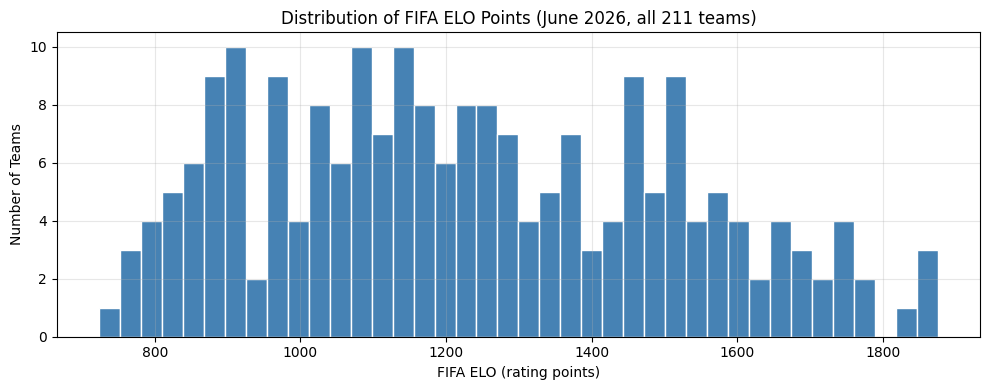

In [89]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(fifa_rank['fifa_elo'], bins=40, color='steelblue', edgecolor='white')
ax.set_title('Distribution of FIFA ELO Points (June 2026, all 211 teams)')
ax.set_xlabel('FIFA ELO (rating points)')
ax.set_ylabel('Number of Teams')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Save Outputs

In [90]:
results.to_csv(OUTPUT_DIR / 'results_clean.csv', index=False)
fifa_rank.to_csv(OUTPUT_DIR / 'fifa_ranking_clean.csv', index=False)

print('Saved:')
print(f'  output/results_clean.csv       ({len(results):,} rows)')
print(f'  output/fifa_ranking_clean.csv  ({len(fifa_rank):,} teams)')

Saved:
  output/results_clean.csv       (49,378 rows)
  output/fifa_ranking_clean.csv  (211 teams)


---
## What's next?

**Notebook 2 — Feature Engineering** will build on these two clean files:
- **Recent form** (last N matches): win rate, goals scored/conceded per game
- **Competitive form** — same metrics but filtered to qualifiers and tournaments only (no friendlies)
- A **match-pair feature table** where each row is one match with ΔELO, Δform, confederation, venue, etc. — ready to feed into a model